In [5]:
!pip install yfinance pandas numpy matplotlib scikit-learn openpyxl

In [11]:
!pip install yfinance

[*********************100%***********************]  1 of 1 completed


Model Performance:
MAE : 7.5064
RMSE: 10.2907
R2  : 0.8742


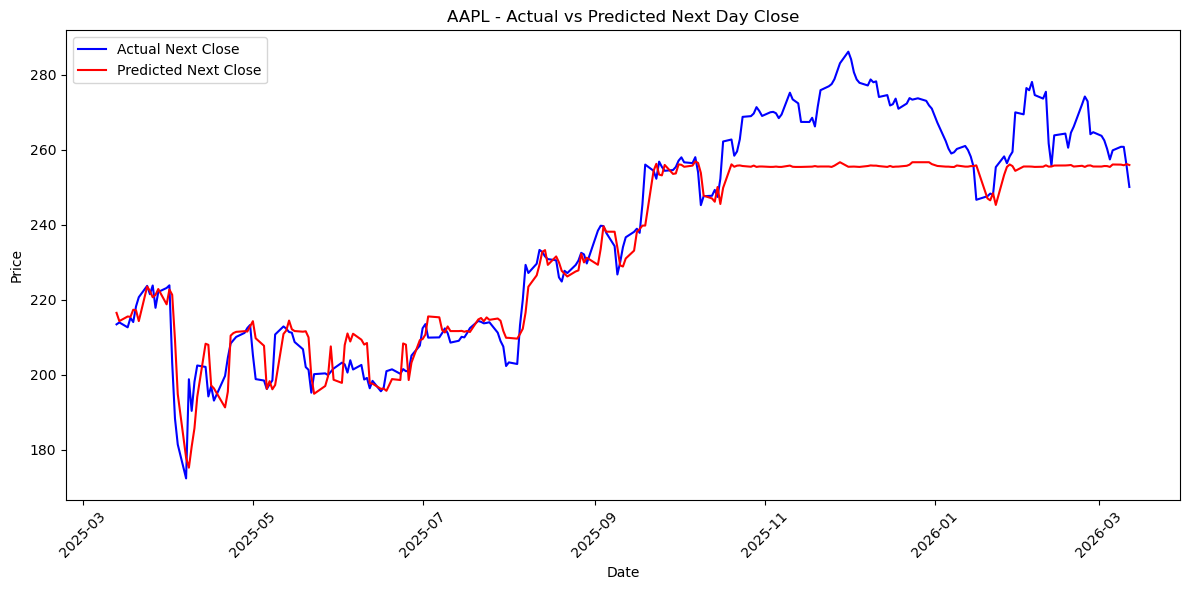


Predicted next closing price for AAPL: 255.97


In [18]:
# Task 2: Predict Future Stock Prices 

# Step 0: Install libraries if needed
# !pip install yfinance pandas numpy matplotlib scikit-learn openpyxl

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------
# Step 1: Choose stock ticker
ticker = "AAPL"  # Can change to TSLA, MSFT, etc.

# Step 2: Download historical stock data
df = yf.download(ticker, period="5y", auto_adjust=False)

# Step 3: Reset index to get Date column
df = df.reset_index()
if 'Date' not in df.columns:
    df['Date'] = df.index

# Step 4: Ensure Close column exists
if 'Close' not in df.columns:
    df['Close'] = df['Adj Close']  # fallback if only Adj Close exists

# Step 5: Prepare target variable (next day's Close)
df['Target_Next_Close'] = df['Close'].shift(-1)

# Step 6: Keep relevant columns & drop NaN
data = df[['Date', 'Open', 'High', 'Low', 'Volume', 'Target_Next_Close']].dropna()

# Step 7: Features and target
X = data[['Open', 'High', 'Low', 'Volume']]
y = data['Target_Next_Close']

# Step 8: Train-test split (chronological)
split_index = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
test_dates = data['Date'].iloc[split_index:]

# Step 9: Train Random Forest model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Step 10: Predictions
y_pred = model.predict(X_test)

# Step 11: Model evaluation
print("Model Performance:")
print("MAE :", round(mean_absolute_error(y_test, y_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))
print("R2  :", round(r2_score(y_test, y_pred), 4))

# Step 12: Plot Actual vs Predicted
plt.figure(figsize=(12,6))
plt.plot(test_dates, y_test.values, label="Actual Next Close", color='blue')
plt.plot(test_dates, y_pred, label="Predicted Next Close", color='red')
plt.xlabel("Date")
plt.ylabel("Price")
plt.title(f"{ticker} - Actual vs Predicted Next Day Close")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 13: Predict next day's close
next_day_prediction = model.predict(X.iloc[[-1]])[0]
print(f"\nPredicted next closing price for {ticker}: {next_day_prediction:.2f}")